In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sqlalchemy import create_engine

In [2]:
engine = create_engine(r"sqlite:///C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\db\bluestock_mf.db")

In [5]:
nav = pd.read_sql("SELECT * FROM fact_nav", engine)
fund = pd.read_sql("SELECT * FROM dim_fund", engine)
performance = pd.read_sql("SELECT * FROM fact_performance", engine)
benchmark = pd.read_sql("SELECT * FROM fact_portfolio", engine)

In [6]:
nav['date'] = pd.to_datetime(nav['date'])

In [7]:
print("All tables loaded")
print(f"NAV: {nav.shape}")
print(f"Fund: {fund.shape}")
print(f"Performance: {performance.shape}")

All tables loaded
NAV: (46000, 3)
Fund: (40, 15)
Performance: (40, 19)


In [8]:
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot.pct_change().dropna()
n = len(daily_returns)
annualised_returns = (1 + daily_returns).prod() ** (252/n) - 1

returns_df = annualised_returns.reset_index()
returns_df.columns = ['amfi_code', 'annualised_return']
returns_df = returns_df.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')

returns_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\returns_computed.csv", index=False)

print("Daily returns computed")
print(returns_df.sort_values('annualised_return', ascending=False).head(10))

Daily returns computed
    amfi_code  annualised_return  \
25     120505           0.315124   
21     119598           0.311266   
39     149324           0.309965   
36     148569           0.306736   
34     148567           0.297414   
30     120843           0.296776   
2      100033           0.289279   
38     149323           0.284096   
16     119094           0.271025   
19     119551           0.247966   

                                          scheme_name  
25           ICICI Pru Midcap Fund - Regular - Growth  
21         SBI Small Cap Fund - Regular Plan - Growth  
39              DSP Small Cap Fund - Regular - Growth  
36      Mirae Asset Tax Saver Fund - Regular - Growth  
34      Mirae Asset Large Cap Fund - Regular - Growth  
30             Kotak Flexicap Fund - Regular - Growth  
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
38                 DSP Midcap Fund - Regular - Growth  
16                Axis Midcap Fund - Regular - Growth  
19          SBI Blue

In [9]:
def compute_cagr(nav_series, years):
    if len(nav_series) < 2:
        return None
    nav_start = nav_series.iloc[0]
    nav_end = nav_series.iloc[-1]
    return (nav_end / nav_start) ** (1/years) - 1

cagr_results = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values[0]
    
    nav_1yr = fund_nav[fund_nav['date'] >= fund_nav['date'].max() - pd.DateOffset(years=1)]
    cagr_1yr = compute_cagr(nav_1yr['nav'], 1)
    
    nav_3yr = fund_nav[fund_nav['date'] >= fund_nav['date'].max() - pd.DateOffset(years=3)]
    cagr_3yr = compute_cagr(nav_3yr['nav'], 3)
    
    cagr_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'cagr_1yr': round(cagr_1yr * 100, 2),
        'cagr_3yr': round(cagr_3yr * 100, 2)
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\cagr_report.csv", index=False)

print("CAGR computed")
print(cagr_df.sort_values('cagr_3yr', ascending=False).head(10))

CAGR computed
    amfi_code                                        scheme_name  cagr_1yr  \
16     119094                Axis Midcap Fund - Regular - Growth     22.26   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth     20.36   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth     13.06   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     53.23   
25     120505           ICICI Pru Midcap Fund - Regular - Growth     29.60   
19     119551          SBI Bluechip Fund - Regular Plan - Growth     60.44   
30     120843             Kotak Flexicap Fund - Regular - Growth     26.66   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth     39.75   
3      101206      ABSL Frontline Equity Fund - Regular - Growth     47.92   
39     149324              DSP Small Cap Fund - Regular - Growth     65.14   

    cagr_3yr  
16     35.11  
34     34.00  
24     32.49  
2      32.44  
25     31.78  
19     30.46  
30     29.58  
36     

In [10]:
Rf = 0.065 / 252

sharpe_results = []

for code in daily_returns.columns:
    fund_returns = daily_returns[code].dropna()
    
    excess_returns = fund_returns - Rf
    sharpe = (excess_returns.mean() / fund_returns.std()) * np.sqrt(252)
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else code
    
    sharpe_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'sharpe_ratio': round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\sharpe_values.csv", index=False)

print("Sharpe Ratio computed")
print(sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10))

Sharpe Ratio computed
    amfi_code                                        scheme_name  sharpe_ratio
34     148567      Mirae Asset Large Cap Fund - Regular - Growth        1.4483
30     120843             Kotak Flexicap Fund - Regular - Growth        1.3067
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth        1.2349
19     119551          SBI Bluechip Fund - Regular Plan - Growth        1.2083
25     120505           ICICI Pru Midcap Fund - Regular - Growth        1.1801
38     149323                 DSP Midcap Fund - Regular - Growth        1.1321
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...        1.0937
9      118632     Nippon India Large Cap Fund - Regular - Growth        1.0817
3      101206      ABSL Frontline Equity Fund - Regular - Growth        1.0272
24     120504          ICICI Pru Bluechip Fund - Direct - Growth        1.0265


In [11]:
sortino_results = []

for code in daily_returns.columns:
    fund_returns = daily_returns[code].dropna()
    
    excess_returns = fund_returns - Rf
    
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)
    
    sortino = (excess_returns.mean() * 252) / downside_std
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else code
    
    sortino_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'sortino_ratio': round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\sortino_values.csv", index=False)

print("Sortino Ratio computed")
print(sortino_df.sort_values('sortino_ratio', ascending=False).head(10))

Sortino Ratio computed
    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   

    sortino_ratio  
34         2.3856  
30         2.3643  
36         2.1469  
19         2.1403  
25         2.0294  
38         1.8751  
9          1.8501  
2          1.8291  
24         1.8053  
3          1.7996  


In [12]:
benchmark = pd.read_sql("SELECT * FROM fact_nav", engine)
bench_indices = pd.read_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\10_benchmark_indices.csv")

print(bench_indices.columns.tolist())
print(bench_indices['index_name'].unique())

['date', 'index_name', 'close_value']
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [13]:
bench_indices['date'] = pd.to_datetime(bench_indices['date'])
nifty100 = bench_indices[bench_indices['index_name'] == 'NIFTY100'].sort_values('date')
nifty100_returns = nifty100.set_index('date')['close_value'].pct_change().dropna()

alpha_beta_results = []

for code in daily_returns.columns:
    fund_returns = daily_returns[code].dropna()
    
    common_dates = fund_returns.index.intersection(nifty100_returns.index)
    fund_ret = fund_returns[common_dates]
    bench_ret = nifty100_returns[common_dates]
    
    if len(common_dates) < 30:
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, fund_ret)
    
    beta = round(slope, 4)
    alpha = round(intercept * 252, 4)
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values
    name = name[0] if len(name) > 0 else code
    
    alpha_beta_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'alpha': alpha,
        'beta': beta,
        'r_squared': round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\alpha_beta.csv", index=False)

print("Alpha & Beta computed")
print(alpha_beta_df.sort_values('alpha', ascending=False).head(10))

Alpha & Beta computed
    amfi_code                                        scheme_name   alpha  \
21     119598         SBI Small Cap Fund - Regular Plan - Growth  0.3034   
39     149324              DSP Small Cap Fund - Regular - Growth  0.3006   
25     120505           ICICI Pru Midcap Fund - Regular - Growth  0.2926   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth  0.2827   
30     120843             Kotak Flexicap Fund - Regular - Growth  0.2733   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.2720   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.2698   
38     149323                 DSP Midcap Fund - Regular - Growth  0.2660   
16     119094                Axis Midcap Fund - Regular - Growth  0.2608   
19     119551          SBI Bluechip Fund - Regular Plan - Growth  0.2320   

      beta  r_squared  
21 -0.0232     0.0001  
39  0.0115     0.0000  
25  0.0005     0.0000  
36  0.0181     0.0002  
30 -0.0228     0.0003

In [14]:
max_dd_results = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    
    name = fund[fund['amfi_code'] == code]['scheme_name'].values[0]
    
    rolling_max = fund_nav['nav'].cummax()
    
    drawdown = (fund_nav['nav'] / rolling_max) - 1
    max_dd = drawdown.min()
    
    max_dd_results.append({
        'amfi_code': code,
        'scheme_name': name,
        'max_drawdown_pct': round(max_dd * 100, 2)
    })

max_dd_df = pd.DataFrame(max_dd_results)
max_dd_df.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\max_drawdown.csv", index=False)

print("Max Drawdown computed")
print(max_dd_df.sort_values('max_drawdown_pct').head(10))

Max Drawdown computed
    amfi_code                                     scheme_name  \
22     119599       SBI Small Cap Fund - Direct Plan - Growth   
17     119095          Axis Small Cap Fund - Regular - Growth   
4      101207          ABSL Small Cap Fund - Regular - Growth   
39     149324           DSP Small Cap Fund - Regular - Growth   
21     119598      SBI Small Cap Fund - Regular Plan - Growth   
7      102886             UTI Mid Cap Fund - Regular - Growth   
0      100016       HDFC Top 100 Fund - Regular Plan - Growth   
29     120842   Kotak Emerging Equity Fund - Regular - Growth   
11     118634  Nippon India Small Cap Fund - Regular - Growth   
15     119093            Axis Bluechip Fund - Direct - Growth   

    max_drawdown_pct  
22            -52.57  
17            -51.68  
4             -35.45  
39            -31.17  
21            -28.71  
7             -28.00  
0             -24.73  
29            -24.00  
11            -23.34  
15            -21.75  


In [15]:
scorecard = fund[['amfi_code', 'scheme_name', 'expense_ratio_pct']].copy()
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code')
scorecard = scorecard.merge(max_dd_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
scorecard = scorecard.merge(cagr_df[['amfi_code', 'cagr_3yr']], on='amfi_code')

scorecard['return_rank'] = scorecard['cagr_3yr'].rank(ascending=True)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=True)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=False)
scorecard['maxdd_rank'] = scorecard['max_drawdown_pct'].rank(ascending=False)

scorecard['composite_score'] = (
    0.30 * scorecard['return_rank'] +
    0.25 * scorecard['sharpe_rank'] +
    0.20 * scorecard['alpha_rank'] +
    0.15 * scorecard['expense_rank'] +
    0.10 * scorecard['maxdd_rank']
)

scorecard['final_score'] = (scorecard['composite_score'] / scorecard['composite_score'].max()) * 100
scorecard['final_score'] = scorecard['final_score'].round(2)

scorecard.to_csv(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\data\processed\fund_scorecard.csv", index=False)

print("Fund Scorecard computed")
print(scorecard[['scheme_name', 'final_score']].sort_values('final_score', ascending=False).head(10))

Fund Scorecard computed
                                          scheme_name  final_score
12           ICICI Pru Midcap Fund - Regular - Growth       100.00
26                Axis Midcap Fund - Regular - Growth        95.56
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...        95.27
34      Mirae Asset Large Cap Fund - Regular - Growth        94.67
22             Kotak Flexicap Fund - Regular - Growth        92.60
11          ICICI Pru Bluechip Fund - Direct - Growth        89.64
2          SBI Small Cap Fund - Regular Plan - Growth        88.91
39              DSP Small Cap Fund - Regular - Growth        88.68
36      Mirae Asset Tax Saver Fund - Regular - Growth        87.50
0           SBI Bluechip Fund - Regular Plan - Growth        86.46


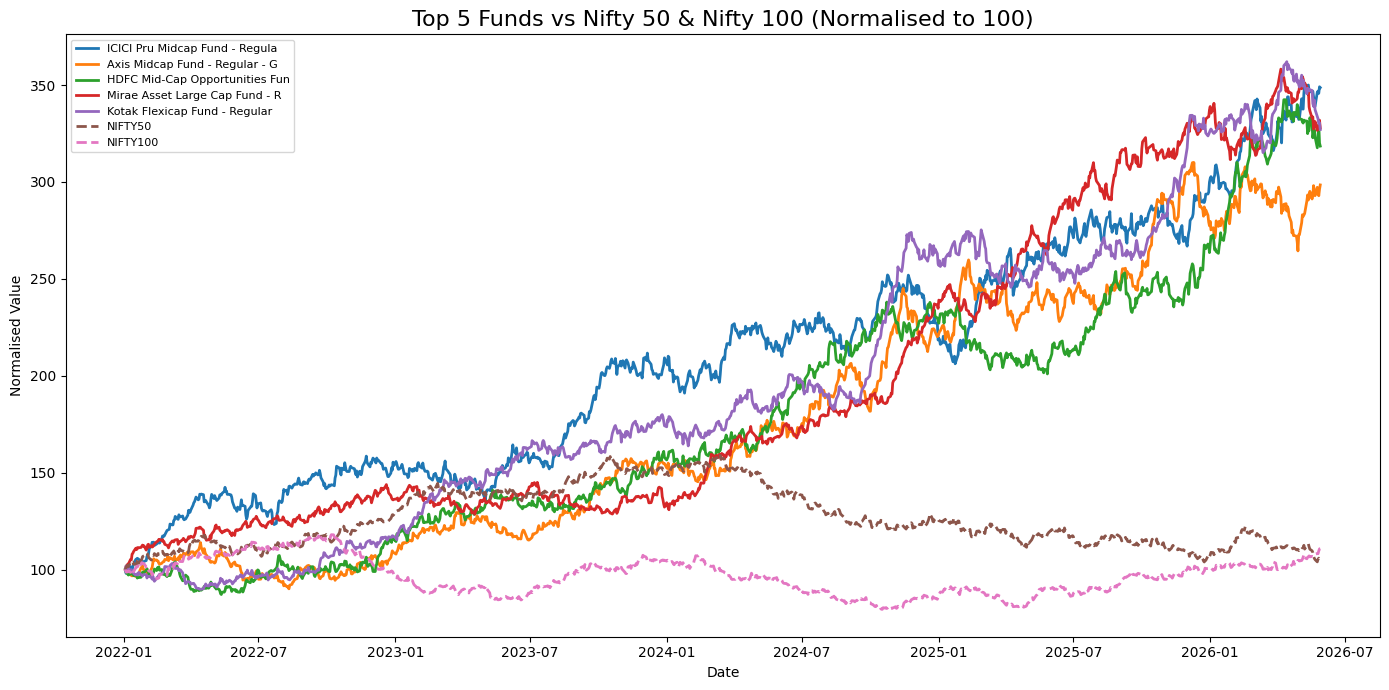

Benchmark chart saved


In [16]:
import matplotlib.pyplot as plt

top5_codes = scorecard.sort_values('final_score', ascending=False).head(5)['amfi_code'].tolist()

top5_nav = nav[nav['amfi_code'].isin(top5_codes)].copy()
top5_nav = top5_nav.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')

plt.figure(figsize=(14, 7))

for code in top5_codes:
    fund_data = top5_nav[top5_nav['amfi_code'] == code].sort_values('date')
    normalised = (fund_data['nav'] / fund_data['nav'].iloc[0]) * 100
    name = fund_data['scheme_name'].iloc[0][:30]
    plt.plot(fund_data['date'], normalised, linewidth=2, label=name)

for index_name in ['NIFTY50', 'NIFTY100']:
    idx = bench_indices[bench_indices['index_name'] == index_name].sort_values('date')
    normalised = (idx['close_value'] / idx['close_value'].iloc[0]) * 100
    plt.plot(idx['date'], normalised, linewidth=2, linestyle='--', label=index_name)

plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (Normalised to 100)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Normalised Value')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(r"C:\Users\ASUS\Desktop\Bluestock_MF_Capstone_Project\reports\benchmark_chart.png", dpi=150)
plt.show()
print("Benchmark chart saved")